In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from numpy import pi as pi
from scipy.integrate import odeint

msun=1.476600 # solar mass in km
dkm = 1.3234e-6 #conversion from Mev/fm^3 to km^-2
cgs1=1.7827e+12 # MeV/fm3 to gms/cm3

def f(rho,kappa,gamma):
    return kappa*(rho**gamma)

def TOV(logrho_c,kappa,gamma):
    dr=0.001
    rho_c=pow(10,logrho_c)*dkm/cgs1
    m=0.0
    r=0.000001
    p=f(rho_c,kappa,gamma)
    e=rho_c+p/(gamma-1.)
    while p >= 0:
        p += -(e+p)*(m+4.0*pi*(r**3.0)*p)*dr/(r*(r-2.0*m))
        if p <= 0:
            break
        m += 4.0*pi*(r**2.0)*e*dr
        r += dr
        e = (p/kappa)**(1.0/gamma)+p/(gamma-1.)
    return m/msun,r

Text(0, 0.5, '$M \\, (M_{\\odot})$')

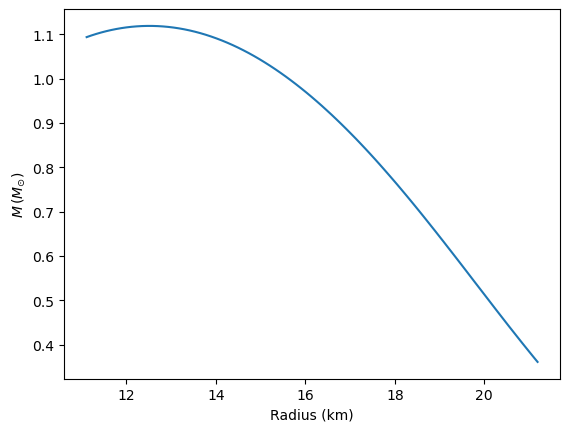

In [2]:
logrho_c_array=np.linspace(14.,15.4,100)
kappa = 110
gamma = 1.9
seq=[]
for logrho_c in logrho_c_array:
    m,r=TOV(logrho_c,kappa,gamma)
    seq.append((m/msun,r))
    
seq=np.vstack(seq)

plt.plot(seq[:,1],seq[:,0])
plt.xlabel('Radius (km)')
plt.ylabel(r'$M \, (M_{\odot})$')

In [22]:
# Number of EOS samples
num_samples = 10000  

EOS_params = np.random.uniform(low=[100., 1.85], 
                               high=[120., 1.95], 
                               size=(num_samples, 2))

# Sample central pressure values (in dyn/cm²)
logrho_c_samples = np.random.uniform(low=14, high=15.5, size=(num_samples, 1))

# Placeholder for Mass, Radius, Tidal Deformability
MR_data = []

# Generate dataset
for i in range(num_samples):
    logrho_c = logrho_c_samples[i, 0]
    params = EOS_params[i]
    M,R = TOV(logrho_c,params[0],params[1])
    MR_data.append([M,R])

# Convert to NumPy array
EOS_data = np.hstack([logrho_c_samples, EOS_params, np.array(MR_data)])

# Save dataset
np.save("EOS_dataset.npy", EOS_data)

In [23]:
EOS_data

array([[ 14.92914863, 103.10315779,   1.87752356,   1.67353546,
         15.678001  ],
       [ 14.0349051 , 100.00819417,   1.87812582,   0.65853423,
         22.396001  ],
       [ 14.67656573, 107.68125685,   1.94509111,   0.85109474,
         14.465001  ],
       ...,
       [ 14.82494999, 102.65390372,   1.89770993,   1.38480359,
         15.639001  ],
       [ 15.18450633, 112.56311643,   1.88254667,   1.79321811,
         13.458001  ],
       [ 15.47543009, 101.96230703,   1.87636764,   1.62854414,
         10.948001  ]])

Epoch [100/1000], Loss: 0.0011
Epoch [200/1000], Loss: 0.0004
Epoch [300/1000], Loss: 0.0002
Epoch [400/1000], Loss: 0.0002
Epoch [500/1000], Loss: 0.0001
Epoch [600/1000], Loss: 0.0001
Epoch [700/1000], Loss: 0.0001
Epoch [800/1000], Loss: 0.0001
Epoch [900/1000], Loss: 0.0001
Epoch [1000/1000], Loss: 0.0001


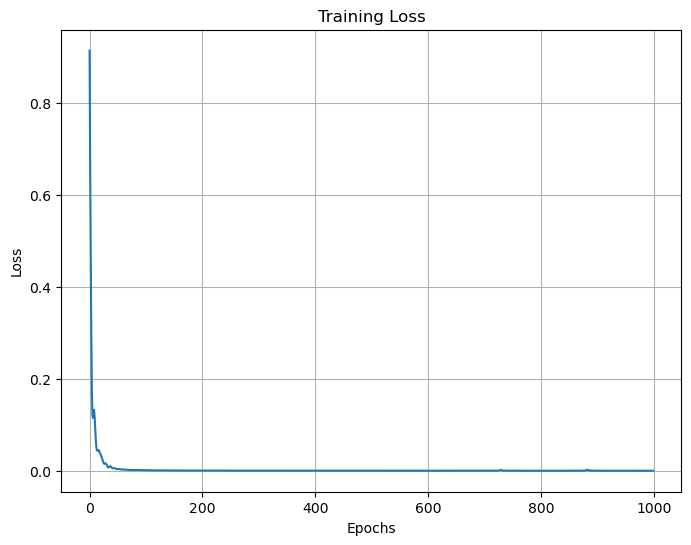

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = np.load("EOS_dataset.npy")
X = torch.tensor(data[:, :3], dtype=torch.float32)  # log_rho_c, kappa, gamma
y = torch.tensor(data[:, 3:5], dtype=torch.float32)  # Mass, Radius

# Normalize the dataset
X_mean, X_std = X.mean(dim=0), X.std(dim=0)
y_mean, y_std = y.mean(dim=0), y.std(dim=0)
X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

# Split into training and validation sets
train_size = int(0.8 * len(X_norm))
X_train, X_val = X_norm[:train_size], X_norm[train_size:]
y_train, y_val = y_norm[:train_size], y_norm[train_size:]

# Convert data to PyTorch tensors
X_train, y_train = X_train.view(-1, 3), y_train.view(-1, 2)
X_val, y_val = X_val.view(-1, 3), y_val.view(-1, 2)

# Define Neural Network
class SimpleNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=50, output_dim=2):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

# Initialize the model
model = SimpleNN()

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training the model
epochs = 1000
losses = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

# Plot Training Loss
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

# Save trained model
torch.save(model.state_dict(), "simple_nn_model.pth")


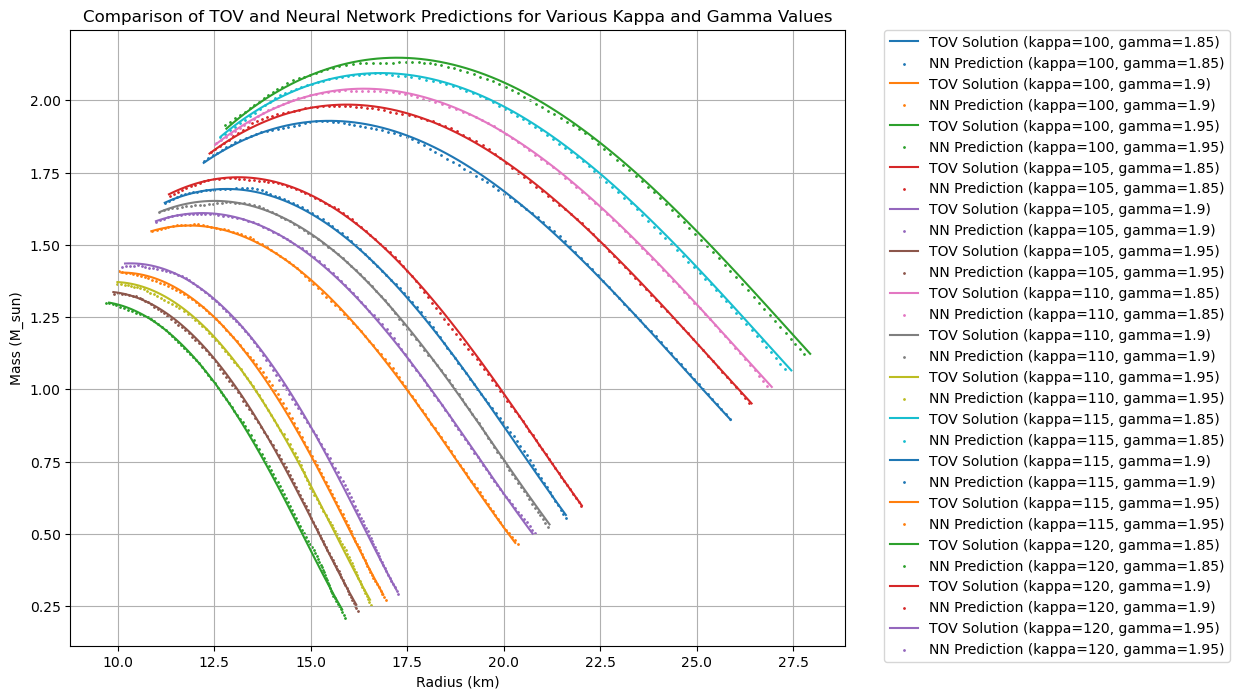

In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Prepare ranges for kappa and gamma
kappa_values = [100, 105, 110, 115, 120]  # Example values for kappa
gamma_values = [1.85, 1.9, 1.95]  # Example values for gamma

# Prepare the array for logrho_c values
logrho_c_array = np.linspace(14., 15.4, 100)

# Initialize lists to store results
predicted_mass = []
predicted_radius = []
original_mass = []
original_radius = []

# Iterate over all kappa and gamma values
for kappa in kappa_values:
    for gamma in gamma_values:
        # Store results for this kappa and gamma combination
        predicted_mass_single = []
        predicted_radius_single = []
        original_mass_single = []
        original_radius_single = []

        for logrho_c in logrho_c_array:
            # Prepare input tensor for prediction
            input_tensor = torch.tensor([[logrho_c, kappa, gamma]], dtype=torch.float32)
            
            # Normalize the input data using the training mean and std
            input_norm = (input_tensor - X_mean) / X_std
            
            # Make predictions with the trained model
            with torch.no_grad():
                prediction = model(input_norm)
            
            # Convert the prediction tensor to NumPy and denormalize the predicted mass and radius
            prediction_np = prediction.detach().numpy()[0]  # Convert to NumPy and get the first element
            
            # Denormalize the predicted mass and radius
            mass_pred, radius_pred = prediction_np * y_std.numpy() + y_mean.numpy()
            
            # Calculate original mass and radius using TOV
            M_orig, R_orig = TOV(logrho_c, kappa, gamma)
            
            # Store the results
            predicted_mass_single.append(mass_pred)
            predicted_radius_single.append(radius_pred)
            original_mass_single.append(M_orig)
            original_radius_single.append(R_orig)

        # After iterating over logrho_c, store the results for each kappa, gamma pair
        predicted_mass.append(predicted_mass_single)
        predicted_radius.append(predicted_radius_single)
        original_mass.append(original_mass_single)
        original_radius.append(original_radius_single)

# Plotting Mass vs Radius for each kappa, gamma combination
plt.figure(figsize=(10, 8))

# Iterate over the stored results and plot each kappa-gamma combination
for i, (kappa, gamma) in enumerate([(k, g) for k in kappa_values for g in gamma_values]):
    plt.plot(original_radius[i], original_mass[i], label=f"TOV Solution (kappa={kappa}, gamma={gamma})", linestyle='-')
    plt.scatter(predicted_radius[i], predicted_mass[i], label=f"NN Prediction (kappa={kappa}, gamma={gamma})", marker='o', s=1)

plt.xlabel("Radius (km)")
plt.ylabel("Mass (M_sun)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Comparison of TOV and Neural Network Predictions for Various Kappa and Gamma Values")
plt.grid()
plt.show()
